In [2]:
from convectio import Mitten

In [3]:
test1 = Mitten(([8, 14]), ([5,6], [3,4]), dirty_qc=True)

Configured IOP 8 with Transects: [5, 6]
Configured IOP 14 with Transects: [3, 4]
QC: Dropped 7278 points from UNL.CoMeTalpha.20240712.1436.L2_2024.p2.f1.rh2.ts2.tf2.w4.nc
QC: Dropped 11880 points from UNL.CoMeTalpha.20240721.1345.L2_2024.p2.f1.rh2.ts2.tf2.w4.nc
Success! Loaded 6931 time steps.
Transects available: ['IOP08_T05_e' 'IOP08_T06_w' 'IOP14_T03_e' 'IOP14_T04_w']


In [4]:
test = test1.extract_tr()
t = test1.transect_dict()
t

{'tr_UID': <StringArray>
 ['IOP08_T05_e', 'IOP08_T06_w', 'IOP14_T03_e', 'IOP14_T04_w']
 Length: 4, dtype: str,
 'lbf_time': <StringArray>
 ['19:16:30', '19:56:44', '17:05:53', '17:49:50']
 Length: 4, dtype: str,
 'tr_direction': <StringArray>
 ['e', 'w', 'e', 'w']
 Length: 4, dtype: str}

In [5]:
from convectio import rel_distance

ds = rel_distance(test, t)
ds

<xarray.Dataset> Size: 721kB
Dimensions:       (time: 6931)
Coordinates:
  * time          (time) datetime64[ns] 55kB 2024-07-12T19:03:00 ... 2024-07-...
    transect_id   (time) object 55kB 'IOP08_T05_e' ... 'IOP14_T04_w'
    ls_distance   (time) float64 55kB 1.64 1.662 1.706 ... 1.509 1.492 1.476
    fr_distance   (time) float64 55kB 19.74 19.72 19.68 ... -18.75 -18.77 -18.78
Data variables: (12/17)
    alt           (time) float32 28kB 190.5 190.6 190.8 ... 191.5 191.3 191.1
    lat           (time) float32 28kB 42.71 42.71 42.71 ... 42.71 42.71 42.71
    lon           (time) float32 28kB -86.19 -86.19 -86.19 ... -86.19 -86.19
    fast_temp     (time) float32 28kB 297.2 297.2 297.4 ... 297.2 297.2 297.3
    slow_temp     (time) float32 28kB 298.4 298.4 298.4 ... 297.5 297.5 297.5
    pressure      (time) float32 28kB 9.972e+04 9.972e+04 ... 9.973e+04
    ...            ...
    dewpoint      (time) float32 28kB 18.59 18.56 18.52 ... 20.54 20.56 20.56
    mixing_ratio  (time) float32 28kB 0.01365 0.01363 ... 0.01547 0.01547
    theta         (time) float32 28kB 297.4 297.4 297.6 ... 297.5 297.5 297.5
    theta_v       (time) float32 28kB 299.9 299.9 300.1 ... 300.3 300.3 300.3
    theta_e       (time) float32 28kB 336.2 336.2 336.3 ... 341.2 341.2 341.3
    error_flag    (time) object 55kB 'g00-p02-tf00-ts00-rh00-f01-w00-a00' ......
Attributes:
    title:        2024-07-12 Combined Mesonet and Tracker synchronized data file
    institution:  Central Michigan University
    source:       Combined Mesonet and Tracker alpha (CoMeT-alpha)
    comment:      PI Contact Info: Jason Keeler (keele1j@cmich.edu)
    description:  All selected transects.

In [34]:
ds['fr_distance'].min()

<xarray.DataArray 'fr_distance' ()> Size: 8B
array(-26.63686803)
Attributes:
    long_name:  Distance to Front (Along Track)
    units:      km

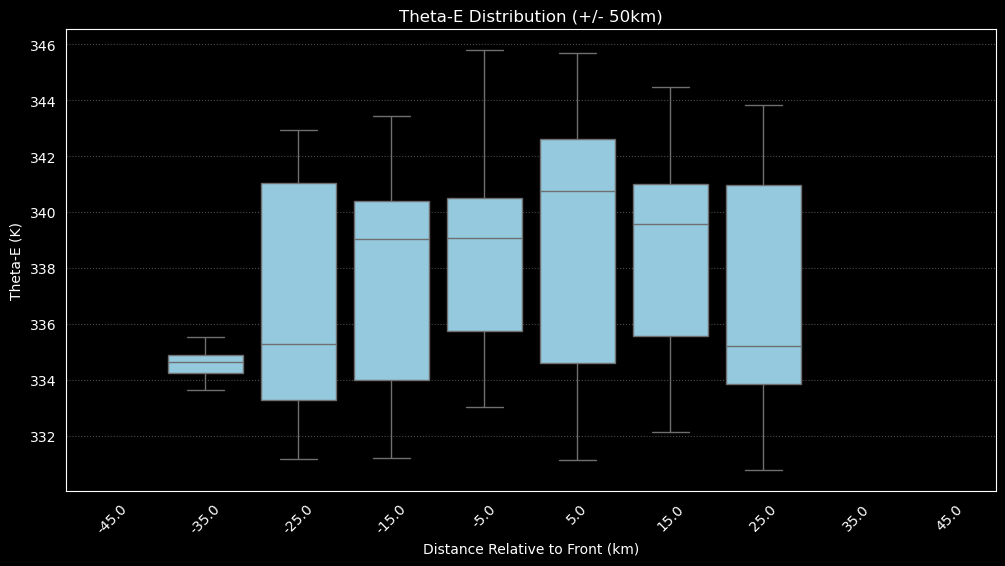

In [6]:
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def bin_dataset_fixed_bound(ds, bin_var, data_var, bin_step, bound):
    """
    Bins a data variable using FIXED, consistent bounds centered on 0.

    Parameters:
    -----------
    bound : int/float
        The maximum distance to include. Bins will range from -bound to +bound.
    bin_step : int/float
        The width of each bin.

    Example: bound=40, bin_step=5 will create bins:
    [-40, -35), [-35, -30) ... [0, 5) ... [35, 40)
    """

    # 1. Grab raw data
    x_data = ds[bin_var].values.flatten()
    y_data = ds[data_var].values.flatten()

    if x_data.size != y_data.size:
        raise ValueError(f"Size mismatch: {x_data.size} vs {y_data.size}")

    # 2. Create DataFrame
    df = pd.DataFrame({bin_var: x_data, data_var: y_data}).dropna()

    # --- 3. FIXED BINNING LOGIC ---

    # Generate edges strictly from -bound to +bound
    # np.arange excludes the stop value, so we add a tiny epsilon or just +bin_step
    # to ensure 'bound' itself is the final edge.
    bins = np.arange(-bound, bound + bin_step, bin_step)

    # Cut the data
    # right=False -> [-40, -35), [-5, 0), [0, 5)
    # This keeps 0.0 exactly in the first POSITIVE bin [0, 5).
    df['bin'] = pd.cut(df[bin_var], bins=bins, right=False)

    # 4. Handle Empty Bins (The "NA" Requirement)
    # pd.cut returns a Categorical series. If a bin has no data, it still exists
    # as a category, but won't show up in a basic groupby unless we force it.

    # Calculate bin centers for plotting
    # We map the center to the 'bin' column
    df['bin_center'] = df['bin'].apply(lambda x: x.mid if not pd.isnull(x) else np.nan)

    return df, bins

# --- Usage Example ---

# Define your fixed bounds (e.g., +/- 40 km) and step (e.g., 5 km)
bound =50
step = 10

df_binned, bin_edges = bin_dataset_fixed_bound(ds,
                                               bin_var='fr_distance',
                                               data_var='theta_e',
                                               bin_step=step,
                                               bound=bound)

# --- Plotting ---
plt.figure(figsize=(12, 6))

# sns.boxplot automatically handles missing data (empty bins simply won't have a box)
# To FORCE empty spots to appear on the axis, we set the 'order' explicitly.
# Calculate all theoretical centers:
all_centers = bin_edges[:-1] + (step / 2)

sns.boxplot(x='bin_center', y='theta_e', data=df_binned,
            color='skyblue',
            order=all_centers) # <--- This is the key to showing "NA" gaps

# Visual Polish
plt.axvline(x=len(all_centers)/2 - 0.5, color='k', linestyle='--', alpha=0.5, label='Front (0 km)')
plt.xticks(rotation=45)
plt.xlabel("Distance Relative to Front (km)")
plt.ylabel("Theta-E (K)")
plt.title(f"Theta-E Distribution (+/- {bound}km)")
plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.show()